In [6]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

conexao = sqlite3.connect("data/crypto.db")

query = """
SELECT dim_moeda.nome_completo, fato_precos.dia, fato_precos.preco_usd
FROM fato_precos
JOIN dim_moeda ON fato_precos.moeda_id = dim_moeda.moeda_id
ORDER BY fato_precos.dia
"""

dados = pd.read_sql(query, conexao)
conexao.close()

dados["dia"] = pd.to_datetime(dados["dia"])

dados.head()

,nome_completo,dia,preco_usd
0,Bitcoin,2026-06-18,63207.036411
1,Ethereum,2026-06-18,1709.573114
2,Bitcoin,2026-06-19,62863.284894
3,Ethereum,2026-06-19,1700.142007
4,Bitcoin,2026-06-20,63673.163806


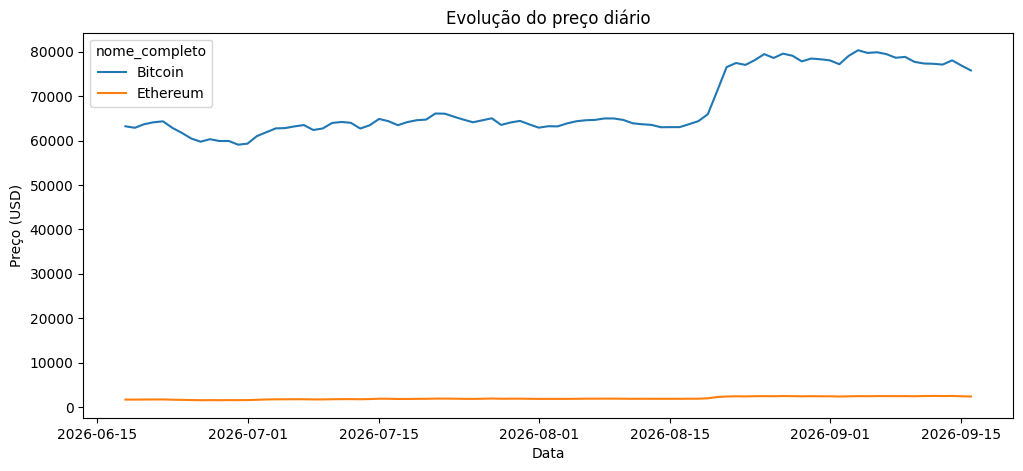

In [7]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=dados, x="dia", y="preco_usd", hue="nome_completo")
plt.title("Evolução do preço diário")
plt.xlabel("Data")
plt.ylabel("Preço (USD)")
plt.show()

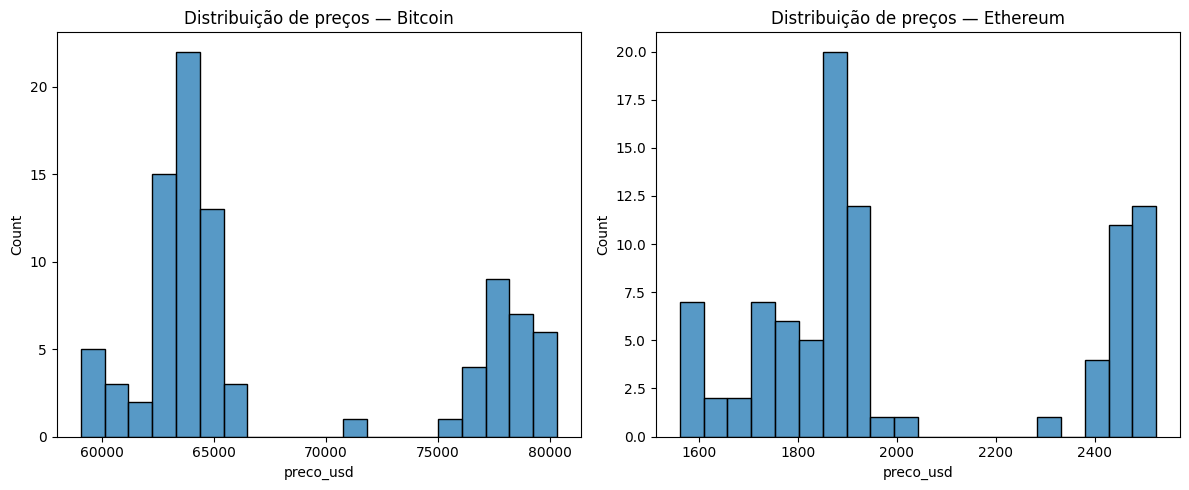

In [8]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 5))

for eixo, moeda in zip(eixos, dados["nome_completo"].unique()):
    subset = dados[dados["nome_completo"] == moeda]
    sns.histplot(subset["preco_usd"], bins=20, ax=eixo)
    eixo.set_title(f"Distribuição de preços — {moeda}")

plt.tight_layout()
plt.show()

In [9]:
dados = dados.sort_values(["nome_completo", "dia"])
dados["retorno_diario"] = dados.groupby("nome_completo")["preco_usd"].pct_change()

dados.head(10)

,nome_completo,dia,preco_usd,retorno_diario
0,Bitcoin,2026-06-18,63207.036411,NaN
2,Bitcoin,2026-06-19,62863.284894,-0.005439
4,Bitcoin,2026-06-20,63673.163806,0.012883
6,Bitcoin,2026-06-21,64105.096100,0.006784
8,Bitcoin,2026-06-22,64316.335690,0.003295
10,Bitcoin,2026-06-23,62845.050617,-0.022876
12,Bitcoin,2026-06-24,61727.349167,-0.017785
14,Bitcoin,2026-06-25,60459.147686,-0.020545
16,Bitcoin,2026-06-26,59737.064895,-0.011943
18,Bitcoin,2026-06-27,60294.384086,0.009330


nome_completo   Bitcoin  Ethereum
nome_completo                    
Bitcoin        1.000000  0.893576
Ethereum       0.893576  1.000000


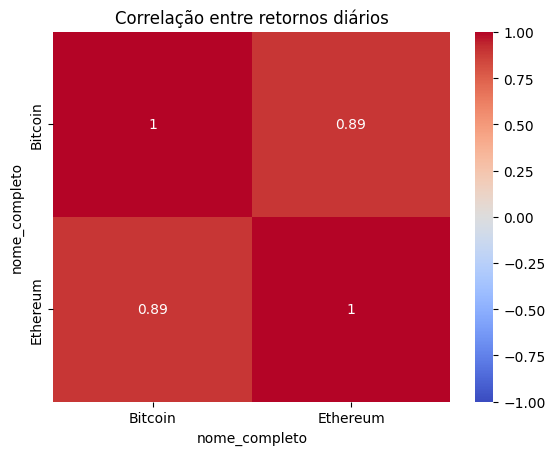

In [10]:
retornos_largura = dados.pivot(index="dia", columns="nome_completo", values="retorno_diario")

correlacao = retornos_largura.corr()
print(correlacao)

sns.heatmap(correlacao, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlação entre retornos diários")
plt.show()

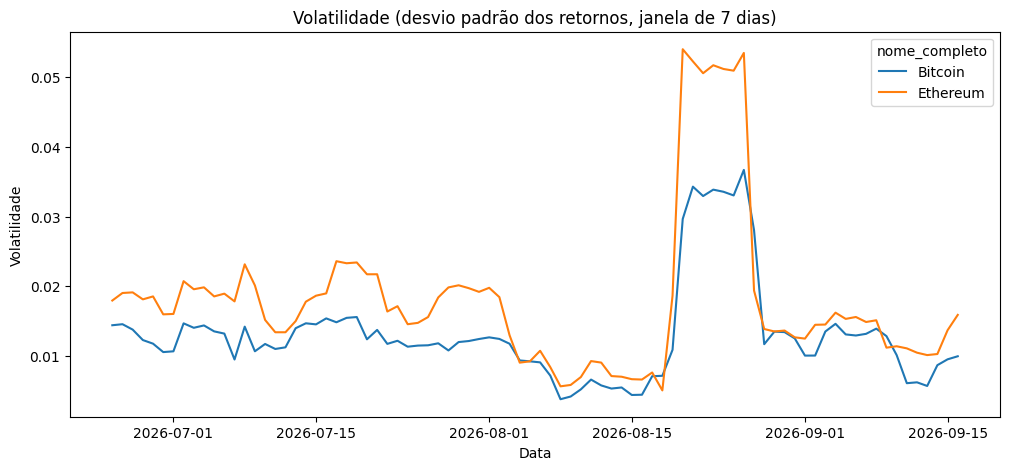

In [11]:
dados["volatilidade_7d"] = dados.groupby("nome_completo")["retorno_diario"].transform(
    lambda x: x.rolling(window=7).std()
)

plt.figure(figsize=(12, 5))
sns.lineplot(data=dados, x="dia", y="volatilidade_7d", hue="nome_completo")
plt.title("Volatilidade (desvio padrão dos retornos, janela de 7 dias)")
plt.xlabel("Data")
plt.ylabel("Volatilidade")
plt.show()

In [12]:
dados["preco_amanha"] = dados.groupby("nome_completo")["preco_usd"].shift(-1)
dados["target"] = (dados["preco_amanha"] > dados["preco_usd"]).astype(int)

In [13]:
def construir_features(grupo):
    grupo = grupo.sort_values("dia").copy()
    grupo["retorno_1d"] = grupo["preco_usd"].pct_change()
    grupo["retorno_medio_3d"] = grupo["retorno_1d"].rolling(3).mean()
    grupo["retorno_medio_7d"] = grupo["retorno_1d"].rolling(7).mean()
    grupo["volatilidade_7d"] = grupo["retorno_1d"].rolling(7).std()
    return grupo

dados_features = dados.groupby("nome_completo", group_keys=False).apply(construir_features)

In [17]:
dados_features = dados.sort_values(["nome_completo", "dia"]).copy()

dados_features["retorno_1d"] = dados_features.groupby("nome_completo")["preco_usd"].pct_change()

dados_features["retorno_medio_3d"] = dados_features.groupby("nome_completo")["retorno_1d"].transform(
    lambda x: x.rolling(3).mean()
)
dados_features["retorno_medio_7d"] = dados_features.groupby("nome_completo")["retorno_1d"].transform(
    lambda x: x.rolling(7).mean()
)
dados_features["volatilidade_7d"] = dados_features.groupby("nome_completo")["retorno_1d"].transform(
    lambda x: x.rolling(7).std()
)

In [18]:
dados_features.head()

,nome_completo,dia,preco_usd,retorno_diario,volatilidade_7d,preco_amanha,target,retorno_1d,retorno_medio_3d,retorno_medio_7d
0,Bitcoin,2026-06-18,63207.036411,NaN,NaN,62863.284894,0,NaN,NaN,NaN
2,Bitcoin,2026-06-19,62863.284894,-0.005439,NaN,63673.163806,1,-0.005439,NaN,NaN
4,Bitcoin,2026-06-20,63673.163806,0.012883,NaN,64105.096100,1,0.012883,NaN,NaN
6,Bitcoin,2026-06-21,64105.096100,0.006784,NaN,64316.335690,1,0.006784,0.004743,NaN
8,Bitcoin,2026-06-22,64316.335690,0.003295,NaN,62845.050617,0,0.003295,0.007654,NaN


In [19]:
pivot_retornos = dados_features.pivot(index="dia", columns="nome_completo", values="retorno_1d")
pivot_retornos.columns = [f"retorno_{c.lower()}" for c in pivot_retornos.columns]

dados_features = dados_features.merge(pivot_retornos, left_on="dia", right_index=True)

In [20]:
dados_features[["nome_completo", "dia", "retorno_bitcoin", "retorno_ethereum"]].head(10)

,nome_completo,dia,retorno_bitcoin,retorno_ethereum
0,Bitcoin,2026-06-18,NaN,NaN
2,Bitcoin,2026-06-19,-0.005439,-0.005517
4,Bitcoin,2026-06-20,0.012883,0.013435
6,Bitcoin,2026-06-21,0.006784,0.003468
8,Bitcoin,2026-06-22,0.003295,0.006145
10,Bitcoin,2026-06-23,-0.022876,-0.034792
12,Bitcoin,2026-06-24,-0.017785,-0.021723
14,Bitcoin,2026-06-25,-0.020545,-0.023221
16,Bitcoin,2026-06-26,-0.011943,-0.026644
18,Bitcoin,2026-06-27,0.009330,0.013828


In [21]:
colunas_features = [
    "retorno_1d", "retorno_medio_3d", "retorno_medio_7d",
    "volatilidade_7d", "retorno_bitcoin", "retorno_ethereum"
]

dataset_modelo = dados_features.dropna(subset=colunas_features + ["target"])

print(dataset_modelo.shape)
dataset_modelo["target"].value_counts()

(168, 12)


target
1    95
0    73
Name: count, dtype: int64

In [22]:
dataset_modelo = dataset_modelo.sort_values("dia")

ponto_corte = int(len(dataset_modelo) * 0.8)

treino = dataset_modelo.iloc[:ponto_corte]
teste = dataset_modelo.iloc[ponto_corte:]

print(treino.shape, teste.shape)
print(treino["dia"].max(), teste["dia"].min())

(134, 12) (34, 12)
2026-08-30 00:00:00 2026-08-31 00:00:00


In [24]:
#treinar o primeiro modelo

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

X_treino = treino[colunas_features]
y_treino = treino["target"]
X_teste = teste[colunas_features]
y_teste = teste["target"]

modelo = LogisticRegression()
modelo.fit(X_treino, y_treino)

previsoes = modelo.predict(X_teste)

print(classification_report(y_teste, previsoes))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        21
           1       0.38      1.00      0.55        13

    accuracy                           0.38        34
   macro avg       0.19      0.50      0.28        34
weighted avg       0.15      0.38      0.21        34



c:\Users\Acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

In [25]:
X_treino.describe()

,retorno_1d,retorno_medio_3d,retorno_medio_7d,volatilidade_7d,retorno_bitcoin,retorno_ethereum
count,134.000000,134.000000,134.000000,134.000000,134.000000,134.000000
mean,0.005062,0.004700,0.004643,0.016479,0.003728,0.006397
std,0.021079,0.015759,0.011202,0.010647,0.017263,0.024229
min,-0.028611,-0.026579,-0.013312,0.003762,-0.022858,-0.028611
25%,-0.006759,-0.003542,-0.001750,0.010730,-0.007439,-0.006261
50%,0.003371,0.002151,0.002268,0.013900,0.003444,0.003299
75%,0.010931,0.007233,0.005738,0.018949,0.010540,0.013265
max,0.144575,0.080408,0.039394,0.054021,0.079751,0.144575


In [26]:
modelo = LogisticRegression(class_weight="balanced")
modelo.fit(X_treino, y_treino)

previsoes = modelo.predict(X_teste)
print(classification_report(y_teste, previsoes, zero_division=0))

              precision    recall  f1-score   support

           0       0.58      0.67      0.62        21
           1       0.30      0.23      0.26        13

    accuracy                           0.50        34
   macro avg       0.44      0.45      0.44        34
weighted avg       0.47      0.50      0.48        34



In [28]:
from lightgbm import LGBMClassifier

modelo_lgbm = LGBMClassifier(random_state=42)
modelo_lgbm.fit(X_treino, y_treino)

previsoes_lgbm = modelo_lgbm.predict(X_teste)
print(classification_report(y_teste, previsoes_lgbm, zero_division=0))

[LightGBM] [Info] Number of positive: 82, number of negative: 52
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000113 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 134, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.611940 -> initscore=0.455476
[LightGBM] [Info] Start training from score 0.455476
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Lig

## Conclusão da modelação

Testámos dois modelos para prever a direção do preço do dia seguinte (sobe/desce), 
usando 90 dias de histórico de Bitcoin e Ethereum, com features de retornos, 
médias móveis, volatilidade e retorno cruzado entre as duas moedas.

**Resultados (accuracy no conjunto de teste, 34 dias):**
- Baseline (prever sempre "sobe"): 56.5%
- Regressão Logística (class_weight="balanced"): 50%
- LightGBM: 56%

**Interpretação:** nenhum dos dois modelos superou a baseline de forma consistente. 
O LightGBM reportou múltiplos avisos de "no further splits with positive gain" — 
sinal direto de que não encontrou padrões exploráveis nos dados.

Isto é consistente com a hipótese do mercado eficiente na sua forma fraca: 
o histórico de preços, isoladamente, não contém sinal suficiente para prever 
a direção do dia seguinte, acima do que se consegue apenas prevendo a classe 
mais frequente.

**Limitações identificadas:**
- Dataset pequeno (134 linhas de treino) — insuficiente para captar sinais fracos e ruidosos
- Apenas features baseadas em preço — sem volume, sentimento de mercado, ou notícias
- Período curto (90 dias) — pode não capturar múltiplos regimes de mercado

**Próximos passos possíveis:** ampliar o histórico (365 dias), incluir volume 
transacionado como feature, ou testar um problema diferente (prever magnitude 
da volatilidade em vez da direção do preço, que tende a ser mais previsível).

In [30]:
import mlflow
import mlflow.sklearn
import mlflow.lightgbm

mlflow.set_experiment("previsao_direcao_cripto")

with mlflow.start_run(run_name="regressao_logistica"):
    modelo_lr = LogisticRegression(class_weight="balanced")
    modelo_lr.fit(X_treino, y_treino)
    previsoes_lr = modelo_lr.predict(X_teste)

    mlflow.log_param("modelo", "LogisticRegression")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_metric("accuracy", accuracy_score(y_teste, previsoes_lr))
    mlflow.log_metric("precision_classe_1", precision_score(y_teste, previsoes_lr, zero_division=0))
    mlflow.log_metric("recall_classe_1", recall_score(y_teste, previsoes_lr, zero_division=0))
    mlflow.sklearn.log_model(modelo_lr, "modelo")

with mlflow.start_run(run_name="lightgbm"):
    modelo_lgbm = LGBMClassifier(random_state=42)
    modelo_lgbm.fit(X_treino, y_treino)
    previsoes_lgbm = modelo_lgbm.predict(X_teste)

    mlflow.log_param("modelo", "LGBMClassifier")
    mlflow.log_param("random_state", 42)
    mlflow.log_metric("accuracy", accuracy_score(y_teste, previsoes_lgbm))
    mlflow.log_metric("precision_classe_1", precision_score(y_teste, previsoes_lgbm, zero_division=0))
    mlflow.log_metric("recall_classe_1", recall_score(y_teste, previsoes_lgbm, zero_division=0))
    mlflow.lightgbm.log_model(modelo_lgbm, "modelo")

print("Experiências registadas com sucesso.")

2026/09/16 19:29:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[LightGBM] [Info] Number of positive: 82, number of negative: 52
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000171 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 134, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.611940 -> initscore=0.455476
[LightGBM] [Info] Start training from score 0.455476
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

2026/09/16 19:30:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Experiências registadas com sucesso.


In [31]:
import joblib

joblib.dump(modelo_lgbm, "data/modelo_lgbm.pkl")
print("Modelo guardado.")

Modelo guardado.
